### 引言

假设我们用MLP处理一个图像（MNIST分类），我们需要先把图像展平，然后对每一个像素和隐藏层神经元进行全连接。
这会产生非常多的参数量，参数量随图片尺寸呈平方级爆炸增长。

因此，能否结合图像的特性，设计一个不需要全连接的模型？

### 局部性 & 平移不变性

MLP通过全连接，可以学习到图片中的很多特性，这些特性往往是不必要的：
1. 图像中各物体之间的关系：比如图像中左上角和右下角物体之间的关联。这种较远距离物体间的关系往往是不需要学习的；
2. 图像中物体所在的位置：比如MLP能够学习到一个物体在图像的左下角。如果另一张图，这个物体出现在了别的位置，可能MLP就不认识了。

以上对应了两个特性：局部性和平移不变性。我们训练的模型应该具有以上特性：
1. 局部性（locality）：神经网络的前面几层应该只探索输入图像中的局部区域，而不过度在意图像中相隔较远区域的关系，这就是“局部性”原则。最终，可以聚合这些局部特征，以在整个图像级别进行预测。
2. 平移不变性（translation invariance）：不管检测对象出现在图像中的哪个位置，神经网络的前面几层应该对相同的图像区域具有相似的反应，即为“平移不变性”。

而MLP不具备以上两种特性，把图拉成线，所有像素一视同仁，参数巨多，位置变了就不认识，并且参数量非常多。

### 卷积神经网络

关于卷积神经网络的原理可以查看[卷积神经网络](https://zh.d2l.ai/chapter_convolutional-neural-networks/conv-layer.html)，本节通过代码来学习：

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# 1. 设置设备 (GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用设备: {device}")

# 2. 定义超参数
num_epochs = 5
batch_size = 64
learning_rate = 0.001

# 3. 数据预处理与加载
# ToTensor() 会自动将图片从 [0, 255] 归一化到 [0, 1] 并转换为 Tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    # 标准化：(x - mean) / std，这里使用 MNIST 的全局均值和标准差
    transforms.Normalize((0.1307,), (0.3081,)) 
])

# 图像形状是 (1,28,28) 
train_dataset = datasets.MNIST(root='data/', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data/', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

当前使用设备: cuda


In [25]:
# 4. 定义 CNN 模型
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 第一个卷积块
        # 输入: 1通道 (灰度图), 输出: 32通道, 卷积核: 3x3。卷积后得到(32,26,26)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        # 池化层: 2x2 窗口，步长 2。池化后得到(32,13,13)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 第二个卷积块
        # 输入: 32通道, 输出: 64通道。卷积后得到(64,11,11)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        # 服用第一个池化层池化。池化后得到(64,5,5)（向下取整）
        # 全连接层
        # 经过两次池化，28x28 的图片变成了 5x5 (具体计算见下文)
        # 输入大小 = 64个通道 * 5 * 5
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10) # 输出 10 个类别

    def forward(self, x):
        # 卷积 -> 激活 -> 池化
        x = self.pool(F.relu(self.conv1(x))) # 输出形状: [64, 32, 13, 13] (28 -> 26 -> 13)
        x = self.pool(F.relu(self.conv2(x))) # 输出形状: [64, 64, 5, 5]   (13 -> 11 -> 5)
        
        # 展平
        x = x.view(-1, 64 * 5 * 5)
        
        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

In [26]:
# 5. 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 6. 训练循环
for epoch in range(num_epochs):
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    for batch_idx, (data, targets) in enumerate(train_loader):
        data, targets = data.to(device), targets.to(device)

        # 前向传播
        scores = model(data)
        loss = criterion(scores, targets)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 每 100 个 batch 打印一次
        if batch_idx % 100 == 0:
            print(f"  Batch: {batch_idx}, Loss: {loss.item():.4f}")

Epoch [1/5]
  Batch: 0, Loss: 2.3286
  Batch: 100, Loss: 0.1821
  Batch: 200, Loss: 0.0910
  Batch: 300, Loss: 0.1527
  Batch: 400, Loss: 0.0339
  Batch: 500, Loss: 0.0454
  Batch: 600, Loss: 0.0300
  Batch: 700, Loss: 0.0965
  Batch: 800, Loss: 0.1319
  Batch: 900, Loss: 0.0230
Epoch [2/5]
  Batch: 0, Loss: 0.0858
  Batch: 100, Loss: 0.0335
  Batch: 200, Loss: 0.0048
  Batch: 300, Loss: 0.0201
  Batch: 400, Loss: 0.0052
  Batch: 500, Loss: 0.0395
  Batch: 600, Loss: 0.1014
  Batch: 700, Loss: 0.0274
  Batch: 800, Loss: 0.0357
  Batch: 900, Loss: 0.0509
Epoch [3/5]
  Batch: 0, Loss: 0.0738
  Batch: 100, Loss: 0.0049
  Batch: 200, Loss: 0.0541
  Batch: 300, Loss: 0.0009
  Batch: 400, Loss: 0.0230
  Batch: 500, Loss: 0.0638
  Batch: 600, Loss: 0.0535
  Batch: 700, Loss: 0.0311
  Batch: 800, Loss: 0.0339
  Batch: 900, Loss: 0.0035
Epoch [4/5]
  Batch: 0, Loss: 0.0587
  Batch: 100, Loss: 0.0017
  Batch: 200, Loss: 0.0247
  Batch: 300, Loss: 0.0846
  Batch: 400, Loss: 0.0075
  Batch: 500, L

In [27]:

# 7. 测试准确率
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval() # 设置为评估模式

    with torch.no_grad(): # 测试时不需要计算梯度
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            _, predictions = scores.max(1) # 获取最大值的索引
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)
        
        acc = (num_correct / num_samples) * 100
        print(f"测试集准确率: {acc:.2f}%")

check_accuracy(test_loader, model)

测试集准确率: 99.28%


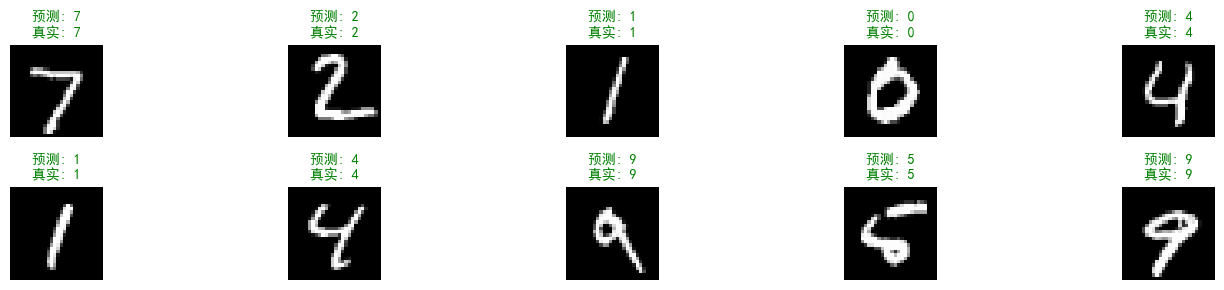

In [29]:
# ==========================================
# 7. 可视化预测结果
# ==========================================
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
# 随便拿一批测试数据看看
iterator = iter(test_loader) # 迭代器
images, labels = next(iterator)
images = images.to(device)
model.eval()
outputs = model(images)
_, predicted = torch.max(outputs.data, 1)

plt.figure(figsize=(15, 3))
for i in range(10): # 显示前10张图
    plt.subplot(2, 5, i+1)
    # 反归一化用于显示 (img * std + mean)
    img = images[i] * 0.3081 + 0.1307 
    plt.imshow(img.squeeze().cpu().numpy(), cmap='gray')
    
    # 预测对了显示绿色，错了显示红色
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f"预测: {predicted[i].item()}\n真实: {labels[i].item()}", color=color, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

显然，使用卷积神经网络比MLP效果好很多。